### Install required packages

In [1]:
!pip install pytesseract opencv-python tensorflow

### Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
from tqdm import tqdm
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from PIL import Image
import pytesseract
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, Concatenate, Add, Activation, UpSampling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping
from tensorflow.keras.applications import VGG19
from tensorflow.keras import regularizers
from tensorflow.keras.applications.densenet import DenseNet121

2025-05-02 16:04:28.636320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746201868.857916      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746201868.921116      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Define custom layers

In [3]:
class table_decoder(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.conv7 = Conv2D(filters=128, kernel_size=(1,1), kernel_regularizer=regularizers.l2(0.001))
        self.upsamp_pool4 = UpSampling2D(size=(2,2), interpolation='bilinear')
        self.upsamp_pool3 = UpSampling2D(size=(2,2), interpolation='bilinear')
        self.upsamp_out = Conv2DTranspose(filters=2, kernel_size=(3,3), strides=2, padding='same', activation='softmax')
        
    def call(self, inp, pool3, pool4):
        x = self.conv7(inp)
        x = self.upsamp_pool4(x)
        x = Concatenate()([x, pool4])
        x = self.upsamp_pool3(x)
        x = Concatenate()([x, pool3])
        x = UpSampling2D((2,2))(x)
        x = UpSampling2D((2,2))(x)
        fin = self.upsamp_out(x)
        return fin

class col_decoder(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.conv7 = Conv2D(filters=128, kernel_size=(1,1), kernel_regularizer=regularizers.l2(0.001), activation='relu')
        self.drop = Dropout(rate=0.8)
        self.conv8 = Conv2D(filters=128, kernel_size=(1,1), kernel_regularizer=regularizers.l2(0.001))
        self.upsamp_pool4 = UpSampling2D((2,2), interpolation='bilinear')
        self.upsamp_pool3 = UpSampling2D((2,2), interpolation='bilinear')
        self.upsamp_out = Conv2DTranspose(filters=2, kernel_size=(3,3), strides=2, padding='same', activation='softmax')
        
    def call(self, inp, pool3, pool4):
        x = self.conv7(inp)
        x = self.drop(x)
        x = self.conv8(x)
        x = self.upsamp_pool4(x)
        x = Concatenate()([x, pool4])
        x = self.upsamp_pool3(x)
        x = Concatenate()([x, pool3])
        x = UpSampling2D((2,2))(x)
        x = UpSampling2D((2,2))(x)
        fin = self.upsamp_out(x)
        return fin

### Build model architecture

In [4]:
# Clear the session
tf.keras.backend.clear_session()

# Define the input
model_input = Input(shape=(1024,1024,3))

# Try loading DenseNet with local weights if available
try:
    encoder = DenseNet121(include_top=False, weights='imagenet', input_tensor=model_input)
except:
    print("Failed to download DenseNet weights, using None weights")
    encoder = DenseNet121(include_top=False, weights=None, input_tensor=model_input)

pool3 = encoder.get_layer('pool3_relu').output
pool4 = encoder.get_layer('pool4_relu').output

# Freeze encoder layers
for layer in encoder.layers:
    layer.trainable = False

# Shared feature processing
conv_6 = Conv2D(filters=512, kernel_size=(1,1), activation='relu', name='block6_conv1',
                kernel_regularizer=regularizers.l2(0.001))(encoder.output)
conv6_drop = Dropout(0.2)(conv_6)

conv_7 = Conv2D(filters=256, kernel_size=(1,1), activation='relu', name='block6_conv2',
                kernel_regularizer=regularizers.l2(0.001))(conv6_drop)
conv7_drop = Dropout(0.2)(conv_7)

# Instantiate the decoders
table_mask = table_decoder()
column_mask = col_decoder()

# Get outputs
table_out = table_mask(conv7_drop, pool3, pool4)
column_out = column_mask(conv7_drop, pool3, pool4)

2025-05-02 16:04:42.856416: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Failed to download DenseNet weights, using None weights


In [5]:
# Build the model
tablenet = Model(inputs=model_input, outputs=[table_out, column_out])

# Print the model summary
tablenet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 1024, 1024, 3)  │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_2          │ (None, 1030, 1030, 3)  │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 512, 512, 64)   │          9,408 │ zero_padding2d_2[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 512, 512, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 512, 512, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_3          │ (None, 514, 514, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 256, 256, 64)   │              0 │ zero_padding2d_3[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 256, 256, 64)   │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 256, 256, 64)   │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 256, 256, 128)  │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 256, 256, 128)  │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 256, 256, 128)  │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 256, 256, 32)   │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 256, 256, 96)   │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 7,835,844 (29.89 MB)

 Trainable params: 798,340 (3.05 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

### Load TableNet weights

In [6]:
# Load weights from Kaggle input directory
tablenet.load_weights('/kaggle/input/marmot-data/DenseNet-Tablenet.h5')
print("Weights loaded successfully!")

Weights loaded successfully!


### Helper functions

In [7]:
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3)
    image = tf.image.resize(image, size=[1024,1024])
    image = tf.cast(image, dtype=tf.float32)/255
    return image

def get_mask_image(mask_pred):
    mask_pred = tf.argmax(mask_pred, axis=-1)
    mask_pred = mask_pred[..., tf.newaxis][0]
    return mask_pred

def filter_table(image, table_mask):
    im = tf.keras.preprocessing.image.array_to_img(image)
    mask = tf.keras.preprocessing.image.array_to_img(table_mask)
    mask = mask.convert('L')
    im.putalpha(mask)
    return im

### Final processing function

In [8]:
def final(path):
    # Load and preprocess image
    image = load_image(path)
    image = tf.reshape(image, shape=(1,1024,1024,3))
    
    # Get predictions
    table_mask_pred, col_mask_pred = tablenet.predict(image)
    table_mask_pred = get_mask_image(table_mask_pred)
    col_mask_pred = get_mask_image(col_mask_pred)

    # Filter table using mask
    table = filter_table(image[0], table_mask_pred)

    # Display results
    fig, ax = plt.subplots(ncols=4, figsize=(20,20))
    ax[0].imshow(image[0])
    ax[0].set_title('Original Image')
    ax[1].imshow(table_mask_pred[:,:,0])
    ax[1].set_title('Predicted Table Mask')
    ax[2].imshow(col_mask_pred[:,:,0])
    ax[2].set_title('Predicted Column Mask')
    ax[3].imshow(table)
    ax[3].set_title('Filtered Table')
    
    for a in ax:
        a.axis('off')
    plt.show()

    # Extract text with OCR
    text_data = pytesseract.image_to_string(table, lang='eng')
    print("Extracted Text using OCR:")
    print(text_data)

    return text_data

### Save Text Data to CSV

In [9]:
import csv
from datetime import datetime

# Function to save text data to CSV
def save_to_csv(text_data, output_file='extracted_table.csv'):
    # Split the text into lines
    lines = text_data.split('\n')
    
    # Remove empty lines
    lines = [line.strip() for line in lines if line.strip()]
    
    # Write to CSV
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        # Write each line as a row (you might need more sophisticated parsing here)
        for line in lines:
            # Split line into cells (this is a simple approach - adjust as needed)
            # For tables, you might want to split on multiple spaces or tabs
            cells = [cell.strip() for cell in line.split('  ') if cell.strip()]
            writer.writerow(cells)
    
    print(f"Data saved to {output_file}")

### Execute with sample image

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


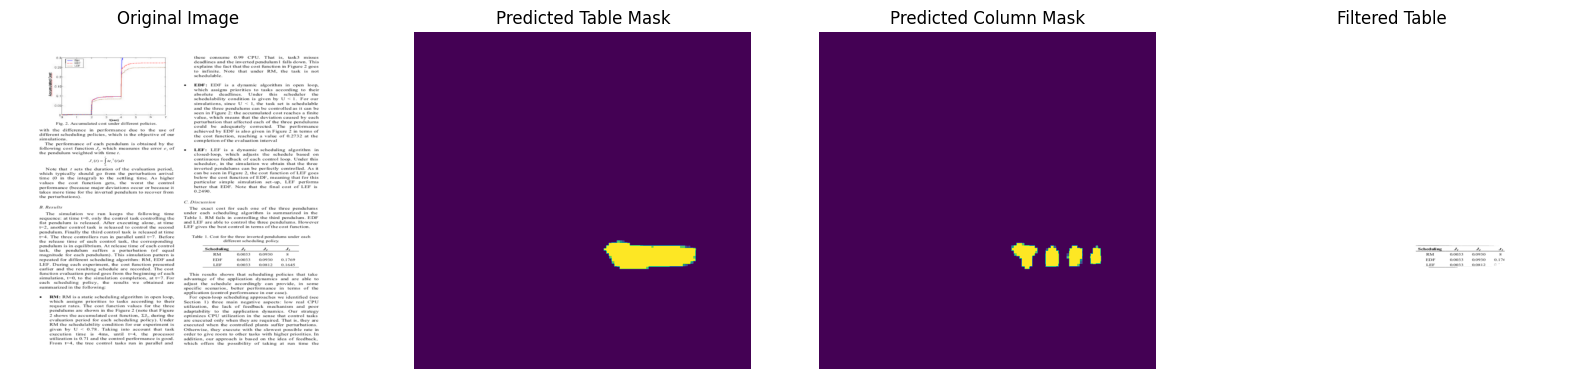

Extracted Text using OCR:
Scheduling J, te ts
RM 0.0033 0.0930 s
EDF 0.0033 0.0930 0.176

0.0033 00812 =

 

Data saved to extracted_table.csv


In [10]:
# Test with a sample image and save to CSV
text_data = final('/kaggle/input/marmot-data/Marmot_data/10.1.1.1.2006_3.bmp')
save_to_csv(text_data)